# US Recession 2025 Forecast - Backtesting Results

This notebook analyzes historical backtesting results for the recession forecast models.

## Objectives
0. Generate backtest data if none exists (runs automatically)
1. Visualize historical performance over time
2. Compare v1 and v2 model performance
3. Calculate and display performance metrics
4. Analyze forecast errors and patterns

**Note:** If no backtest data exists, this notebook will generate it automatically. This may take several minutes.

In [18]:
# Add project root to path
import sys
from pathlib import Path

# Add project root (3 levels up from this notebook)
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/simon/Documents/perso/polymarket-simulator


In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Define colors
RECESSION_COLOR = '#ff6b6b'
V1_COLOR = '#4ecdc4'
V2_COLOR = '#45b7d1'

print("✓ Libraries imported")

✓ Libraries imported


In [20]:
# Import backtesting engine and models
from forecasts.us_recession_2025.backtesting import BacktestEngine
from forecasts.us_recession_2025.model import RecessionModel
from forecasts.us_recession_2025.model_v2 import RecessionModelV2

print("✓ Backtesting engine imported")

✓ Backtesting engine imported


## 0. Generate Backtest Data (if needed)

First, let's check if we have backtest data. If not, we'll generate it.

**Note:** Backtesting can take several minutes depending on the date range.

In [21]:
# Check for existing backtest data
engine_check = BacktestEngine(model_version='v2')
existing_v2 = engine_check.get_backtest_results(model_version='v2')

print(f"Existing v2 backtest results: {len(existing_v2)}")

if len(existing_v2) < 10:
    print("\n⚠️  Insufficient backtest data found.")
    print("We'll generate backtest data for the past year.")
    print("This may take a few minutes...\n")
    NEED_TO_RUN_BACKTEST = True
else:
    print("\n✓ Sufficient backtest data found. Skipping backtest generation.")
    NEED_TO_RUN_BACKTEST = False

Existing v2 backtest results: 4

⚠️  Insufficient backtest data found.
We'll generate backtest data for the past year.
This may take a few minutes...



In [22]:
# Generate backtest data if needed
if NEED_TO_RUN_BACKTEST:
    print("Generating backtest data...\n")
    
    # Initialize v2 model
    model_v2 = RecessionModelV2()
    
    # Define backtest period (past year, weekly)
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365)
    
    print(f"Running v2 backtest from {start_date.date()} to {end_date.date()}")
    print("Frequency: weekly\n")
    
    # Run backtest
    engine_v2 = BacktestEngine(model_version='v2')
    v2_backtest_results = engine_v2.run_backtest(
        start_date=start_date,
        end_date=end_date,
        frequency='weekly',
        model_instance=model_v2
    )
    
    print(f"\n✓ Generated {len(v2_backtest_results)} v2 backtest results")
    print("\nNote: V1 model doesn't support historical backtesting (no as_of_date parameter).")
    print("For comparison, you would need to modify the v1 model or use current data only.")
else:
    print("Skipping backtest generation - using existing data.")

Generating backtest data...

Running v2 backtest from 2024-11-22 to 2025-11-22
Frequency: weekly



No observations returned for leading_indicators (series: USSLIND)
FRED API request failed with status 400: Bad Request.  The series does not exist.
Failed to fetch manufacturing_pmi: FRED API request failed with status 400: Bad Request.  The series does not exist.
leading_indicators not available, using neutral default value of 0.0
manufacturing_pmi not available, using neutral default value of 50.0
No observations returned for leading_indicators (series: USSLIND)
FRED API request failed with status 400: Bad Request.  The series does not exist.
Failed to fetch manufacturing_pmi: FRED API request failed with status 400: Bad Request.  The series does not exist.
leading_indicators not available, using neutral default value of 0.0
manufacturing_pmi not available, using neutral default value of 50.0
No observations returned for leading_indicators (series: USSLIND)
FRED API request failed with status 400: Bad Request.  The series does not exist.
Failed to fetch manufacturing_pmi: FRED API re


✓ Generated 23 v2 backtest results

Note: V1 model doesn't support historical backtesting (no as_of_date parameter).
For comparison, you would need to modify the v1 model or use current data only.


## 1. Load Historical Backtest Results

Load backtest results from the database for both v1 and v2 models.

In [23]:
# Initialize backtesting engines
engine_v1 = BacktestEngine(model_version='v1')
engine_v2 = BacktestEngine(model_version='v2')

# Load all backtest results
print("Loading v1 backtest results...")
v1_results = engine_v1.get_backtest_results(model_version='v1')

print("Loading v2 backtest results...")
v2_results = engine_v2.get_backtest_results(model_version='v2')

print(f"\n✓ Loaded {len(v1_results)} v1 backtest results")
print(f"✓ Loaded {len(v2_results)} v2 backtest results")

Loading v1 backtest results...
Loading v2 backtest results...

✓ Loaded 0 v1 backtest results
✓ Loaded 27 v2 backtest results


In [24]:
# Convert to DataFrames for easier analysis
if v1_results:
    df_v1 = pd.DataFrame([
        {
            'date': r['backtest_date'],
            'probability': r.get('adjusted_probability') or r.get('base_probability'),
            'days_remaining': r['days_remaining'],
            'model': 'v1'
        }
        for r in v1_results
    ])
    df_v1['date'] = pd.to_datetime(df_v1['date'])
    print(f"V1 DataFrame: {len(df_v1)} rows")
    print(f"Date range: {df_v1['date'].min()} to {df_v1['date'].max()}")
else:
    df_v1 = pd.DataFrame()
    print("No v1 backtest results available")

if v2_results:
    df_v2 = pd.DataFrame([
        {
            'date': r['backtest_date'],
            'base_probability': r.get('base_probability'),
            'adjusted_probability': r.get('adjusted_probability'),
            'days_remaining': r['days_remaining'],
            'model': 'v2'
        }
        for r in v2_results
    ])
    df_v2['date'] = pd.to_datetime(df_v2['date'])
    print(f"\nV2 DataFrame: {len(df_v2)} rows")
    print(f"Date range: {df_v2['date'].min()} to {df_v2['date'].max()}")
else:
    df_v2 = pd.DataFrame()
    print("\nNo v2 backtest results available")

No v1 backtest results available

V2 DataFrame: 27 rows
Date range: 2024-11-22 00:00:00 to 2025-11-22 00:00:00


## 2. Visualize Historical Performance

Plot probability evolution over time with recession periods marked.

In [25]:
# Define known recession periods (NBER dates)
# Note: These are historical recessions, not the 2025 forecast target
recession_periods = [
    (datetime(2001, 3, 1), datetime(2001, 11, 1)),   # Dot-com bubble
    (datetime(2007, 12, 1), datetime(2009, 6, 1)),   # Great Recession
    (datetime(2020, 2, 1), datetime(2020, 4, 1)),    # COVID-19
]

print(f"Defined {len(recession_periods)} historical recession periods")

Defined 3 historical recession periods


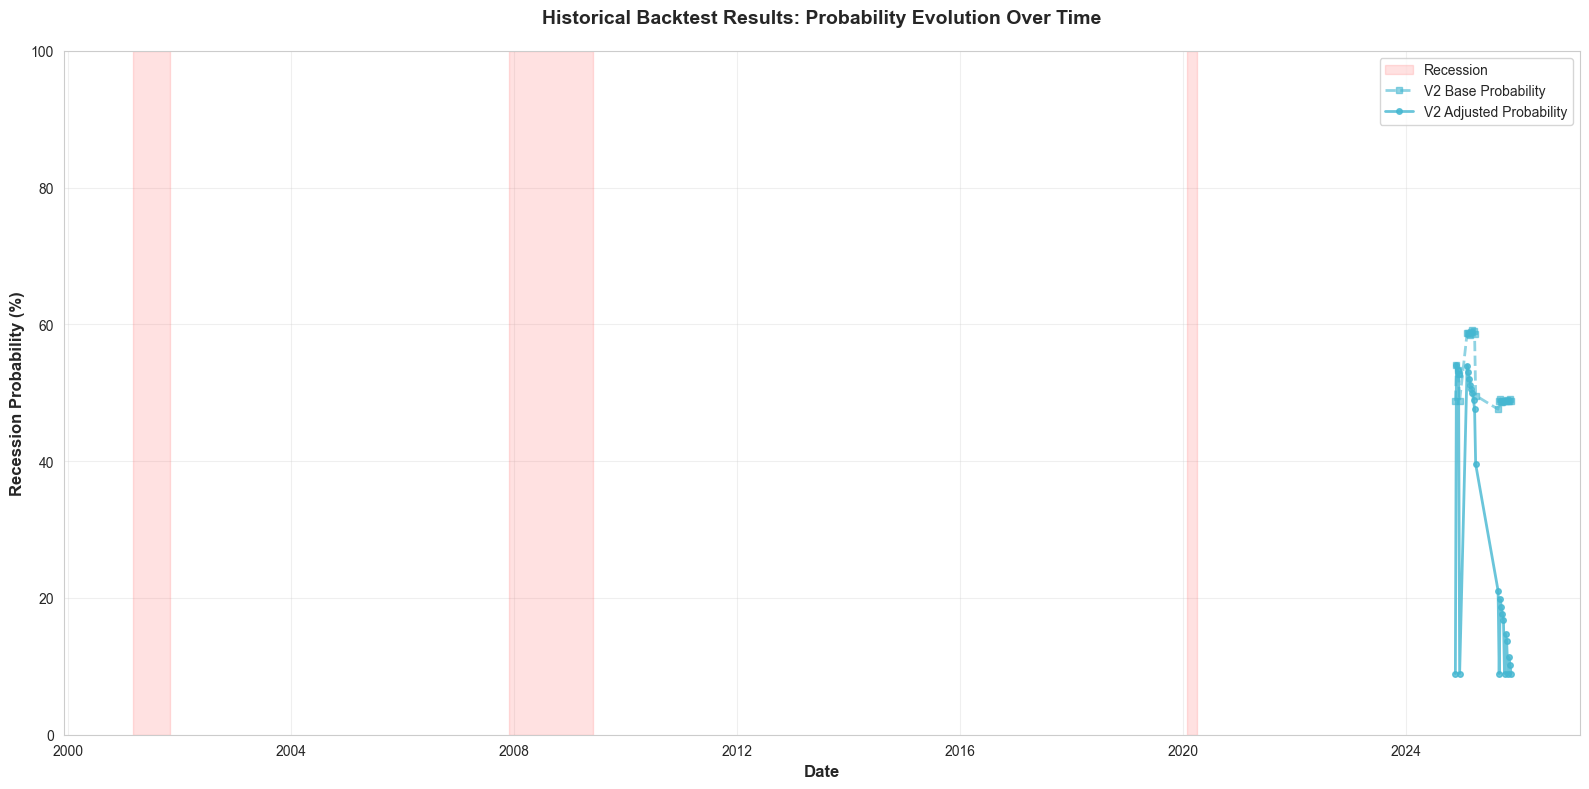

✓ Probability evolution chart created


In [26]:
# Plot probability evolution over time
fig, ax = plt.subplots(figsize=(16, 8))

# Mark recession periods
for start, end in recession_periods:
    ax.axvspan(start, end, alpha=0.2, color=RECESSION_COLOR, label='Recession' if start == recession_periods[0][0] else '')

# Plot v1 results
if not df_v1.empty:
    ax.plot(df_v1['date'], df_v1['probability'] * 100, 
            marker='o', markersize=4, linewidth=2, 
            color=V1_COLOR, label='V1 Model', alpha=0.8)

# Plot v2 results (both base and adjusted)
if not df_v2.empty:
    ax.plot(df_v2['date'], df_v2['base_probability'] * 100, 
            marker='s', markersize=4, linewidth=2, linestyle='--',
            color=V2_COLOR, label='V2 Base Probability', alpha=0.6)
    ax.plot(df_v2['date'], df_v2['adjusted_probability'] * 100, 
            marker='o', markersize=4, linewidth=2, 
            color=V2_COLOR, label='V2 Adjusted Probability', alpha=0.8)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Recession Probability (%)', fontsize=12, fontweight='bold')
ax.set_title('Historical Backtest Results: Probability Evolution Over Time', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("✓ Probability evolution chart created")

In [27]:
# Create side-by-side comparison if both models have data
if not df_v1.empty and not df_v2.empty:
    # Merge on date for direct comparison
    df_merged = pd.merge(df_v1[['date', 'probability']], 
                         df_v2[['date', 'adjusted_probability']], 
                         on='date', how='inner', suffixes=('_v1', '_v2'))
    
    if not df_merged.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Scatter plot: V1 vs V2
        ax1.scatter(df_merged['probability'] * 100, 
                   df_merged['adjusted_probability'] * 100,
                   alpha=0.6, s=50, color=V2_COLOR)
        ax1.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect Agreement')
        ax1.set_xlabel('V1 Probability (%)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('V2 Adjusted Probability (%)', fontsize=11, fontweight='bold')
        ax1.set_title('V1 vs V2 Model Comparison', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, 100)
        ax1.set_ylim(0, 100)
        
        # Difference over time
        df_merged['difference'] = (df_merged['adjusted_probability'] - df_merged['probability']) * 100
        ax2.plot(df_merged['date'], df_merged['difference'], 
                marker='o', markersize=4, linewidth=2, color='#e74c3c')
        ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Difference (V2 - V1) (%)', fontsize=11, fontweight='bold')
        ax2.set_title('Probability Difference Over Time', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Comparison charts created for {len(df_merged)} matching dates")
        print(f"Mean difference: {df_merged['difference'].mean():.2f}%")
        print(f"Std difference: {df_merged['difference'].std():.2f}%")
    else:
        print("No overlapping dates between v1 and v2 results")
else:
    print("Cannot create comparison - need both v1 and v2 results")

Cannot create comparison - need both v1 and v2 results


## 3. Calculate and Display Performance Metrics

Calculate Brier score, calibration statistics, and other performance metrics.

In [28]:
# Calculate performance metrics for both models
print("Calculating performance metrics...\n")

# Calculate metrics for v1
if v1_results:
    v1_metrics = engine_v1.calculate_performance_metrics(v1_results, recession_periods)
    print("V1 Model Performance Metrics:")
    print(f"  Brier Score: {v1_metrics['brier_score']:.4f}" if v1_metrics['brier_score'] is not None else "  Brier Score: N/A")
    print(f"  Mean Probability: {v1_metrics['mean_probability']:.4f}" if v1_metrics['mean_probability'] is not None else "  Mean Probability: N/A")
    print(f"  Sharpness (Std Dev): {v1_metrics['sharpness']:.4f}" if v1_metrics['sharpness'] is not None else "  Sharpness: N/A")
    print(f"  Calibration Slope: {v1_metrics['calibration_slope']:.4f}" if v1_metrics['calibration_slope'] is not None else "  Calibration Slope: N/A")
    print(f"  Calibration Intercept: {v1_metrics['calibration_intercept']:.4f}" if v1_metrics['calibration_intercept'] is not None else "  Calibration Intercept: N/A")
    print(f"  Number of Forecasts: {v1_metrics['num_forecasts']}")
else:
    v1_metrics = None
    print("V1 Model: No results available")

print()

# Calculate metrics for v2
if v2_results:
    v2_metrics = engine_v2.calculate_performance_metrics(v2_results, recession_periods)
    print("V2 Model Performance Metrics:")
    print(f"  Brier Score: {v2_metrics['brier_score']:.4f}" if v2_metrics['brier_score'] is not None else "  Brier Score: N/A")
    print(f"  Mean Probability: {v2_metrics['mean_probability']:.4f}" if v2_metrics['mean_probability'] is not None else "  Mean Probability: N/A")
    print(f"  Sharpness (Std Dev): {v2_metrics['sharpness']:.4f}" if v2_metrics['sharpness'] is not None else "  Sharpness: N/A")
    print(f"  Calibration Slope: {v2_metrics['calibration_slope']:.4f}" if v2_metrics['calibration_slope'] is not None else "  Calibration Slope: N/A")
    print(f"  Calibration Intercept: {v2_metrics['calibration_intercept']:.4f}" if v2_metrics['calibration_intercept'] is not None else "  Calibration Intercept: N/A")
    print(f"  Number of Forecasts: {v2_metrics['num_forecasts']}")
else:
    v2_metrics = None
    print("V2 Model: No results available")

Calculating performance metrics...

V1 Model: No results available

V2 Model Performance Metrics:
  Brier Score: 0.1251
  Mean Probability: 0.2980
  Sharpness (Std Dev): 0.1904
  Calibration Slope: -0.0000
  Calibration Intercept: 0.0000
  Number of Forecasts: 27


In [29]:
# Compare v1 and v2 models
if v1_results and v2_results:
    print("\nComparing V1 and V2 Models...\n")
    comparison = engine_v2.compare_models(v1_results, v2_results, recession_periods)
    
    print("Model Comparison Results:")
    if comparison['brier_score_improvement'] is not None:
        print(f"  Brier Score Improvement: {comparison['brier_score_improvement']:.4f}")
        print(f"  Relative Improvement: {comparison['relative_improvement_pct']:.2f}%")
        print(f"  V2 is Better: {comparison['v2_is_better']}")
    else:
        print("  Unable to calculate improvement metrics")
else:
    print("\nCannot compare models - need both v1 and v2 results")


Cannot compare models - need both v1 and v2 results


In [30]:
# Visualize metrics comparison
if v1_metrics and v2_metrics and v1_metrics['brier_score'] is not None and v2_metrics['brier_score'] is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Brier Score comparison
    ax1 = axes[0]
    models = ['V1', 'V2']
    brier_scores = [v1_metrics['brier_score'], v2_metrics['brier_score']]
    colors = [V1_COLOR, V2_COLOR]
    ax1.bar(models, brier_scores, color=colors, alpha=0.7)
    ax1.set_ylabel('Brier Score (lower is better)', fontsize=10, fontweight='bold')
    ax1.set_title('Brier Score Comparison', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Mean probability comparison
    ax2 = axes[1]
    mean_probs = [v1_metrics['mean_probability'], v2_metrics['mean_probability']]
    ax2.bar(models, mean_probs, color=colors, alpha=0.7)
    ax2.set_ylabel('Mean Probability', fontsize=10, fontweight='bold')
    ax2.set_title('Mean Probability Comparison', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Sharpness comparison
    ax3 = axes[2]
    sharpness = [v1_metrics['sharpness'], v2_metrics['sharpness']]
    ax3.bar(models, sharpness, color=colors, alpha=0.7)
    ax3.set_ylabel('Sharpness (Std Dev)', fontsize=10, fontweight='bold')
    ax3.set_title('Forecast Sharpness Comparison', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Metrics comparison charts created")
else:
    print("Cannot create metrics comparison charts - insufficient data")

Cannot create metrics comparison charts - insufficient data


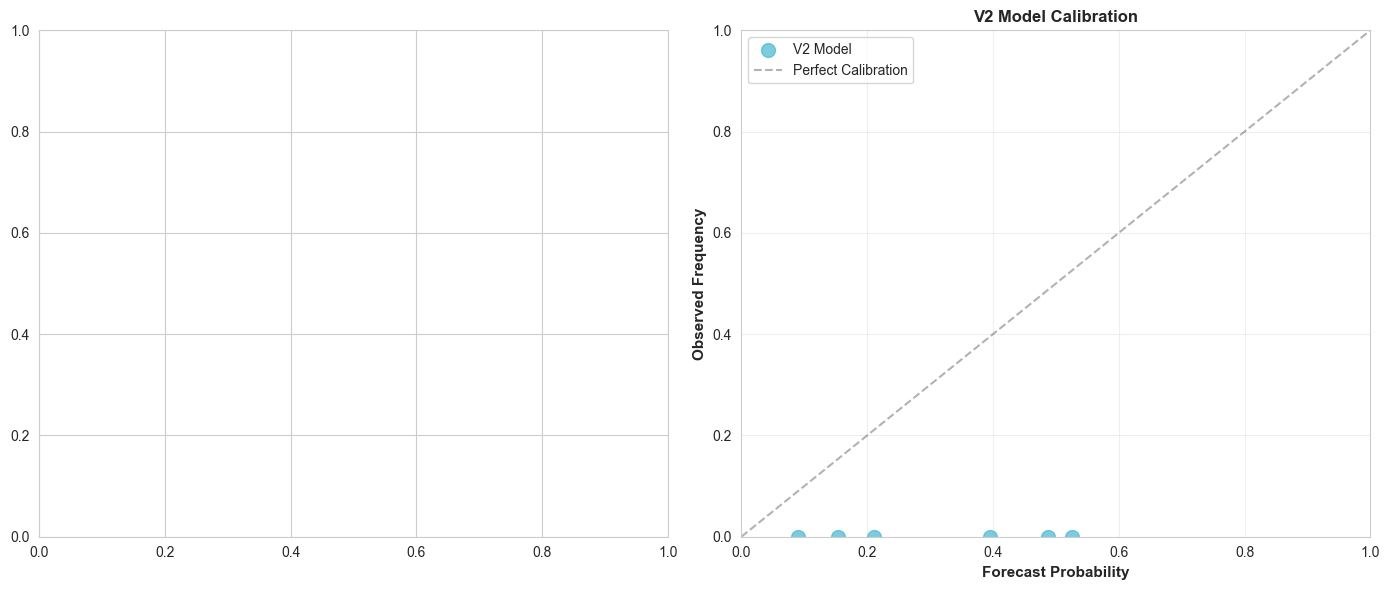

✓ Calibration plots created


In [31]:
# Create calibration plot
def create_calibration_plot(results, recession_periods, model_name, color):
    """Create a calibration plot for a model."""
    if not results:
        return None, None
    
    # Extract probabilities and outcomes
    probs = []
    outcomes = []
    
    for r in results:
        prob = r.get('adjusted_probability') or r.get('base_probability')
        if prob is not None:
            probs.append(prob)
            
            # Check if in recession
            date = r['backtest_date']
            in_recession = any(start <= date <= end for start, end in recession_periods)
            outcomes.append(1.0 if in_recession else 0.0)
    
    if not probs:
        return None, None
    
    # Bin probabilities and calculate observed frequencies
    bins = np.linspace(0, 1, 11)  # 10 bins
    bin_indices = np.digitize(probs, bins) - 1
    
    bin_means = []
    bin_freqs = []
    
    for i in range(len(bins) - 1):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_means.append(np.mean([probs[j] for j in range(len(probs)) if mask[j]]))
            bin_freqs.append(np.mean([outcomes[j] for j in range(len(outcomes)) if mask[j]]))
    
    return bin_means, bin_freqs

# Create calibration plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# V1 calibration
if v1_results:
    v1_bin_means, v1_bin_freqs = create_calibration_plot(v1_results, recession_periods, 'V1', V1_COLOR)
    if v1_bin_means:
        ax1.scatter(v1_bin_means, v1_bin_freqs, s=100, alpha=0.7, color=V1_COLOR, label='V1 Model')
        ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')
        ax1.set_xlabel('Forecast Probability', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Observed Frequency', fontsize=11, fontweight='bold')
        ax1.set_title('V1 Model Calibration', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)

# V2 calibration
if v2_results:
    v2_bin_means, v2_bin_freqs = create_calibration_plot(v2_results, recession_periods, 'V2', V2_COLOR)
    if v2_bin_means:
        ax2.scatter(v2_bin_means, v2_bin_freqs, s=100, alpha=0.7, color=V2_COLOR, label='V2 Model')
        ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')
        ax2.set_xlabel('Forecast Probability', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Observed Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('V2 Model Calibration', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("✓ Calibration plots created")

## 4. Analyze Forecast Errors

Identify periods of over/under-prediction and analyze error patterns.

In [32]:
# Calculate forecast errors (forecast - actual)
def calculate_errors(results, recession_periods):
    """Calculate forecast errors."""
    errors = []
    dates = []
    
    for r in results:
        prob = r.get('adjusted_probability') or r.get('base_probability')
        if prob is not None:
            date = r['backtest_date']
            in_recession = any(start <= date <= end for start, end in recession_periods)
            actual = 1.0 if in_recession else 0.0
            error = prob - actual
            errors.append(error)
            dates.append(date)
    
    return dates, errors

# Calculate errors for both models
if v1_results:
    v1_dates, v1_errors = calculate_errors(v1_results, recession_periods)
    print(f"V1 Model Errors:")
    print(f"  Mean Error: {np.mean(v1_errors):.4f}")
    print(f"  Mean Absolute Error: {np.mean(np.abs(v1_errors)):.4f}")
    print(f"  RMSE: {np.sqrt(np.mean(np.array(v1_errors)**2)):.4f}")
else:
    v1_dates, v1_errors = [], []
    print("V1 Model: No results available")

print()

if v2_results:
    v2_dates, v2_errors = calculate_errors(v2_results, recession_periods)
    print(f"V2 Model Errors:")
    print(f"  Mean Error: {np.mean(v2_errors):.4f}")
    print(f"  Mean Absolute Error: {np.mean(np.abs(v2_errors)):.4f}")
    print(f"  RMSE: {np.sqrt(np.mean(np.array(v2_errors)**2)):.4f}")
else:
    v2_dates, v2_errors = [], []
    print("V2 Model: No results available")

V1 Model: No results available

V2 Model Errors:
  Mean Error: 0.2980
  Mean Absolute Error: 0.2980
  RMSE: 0.3537


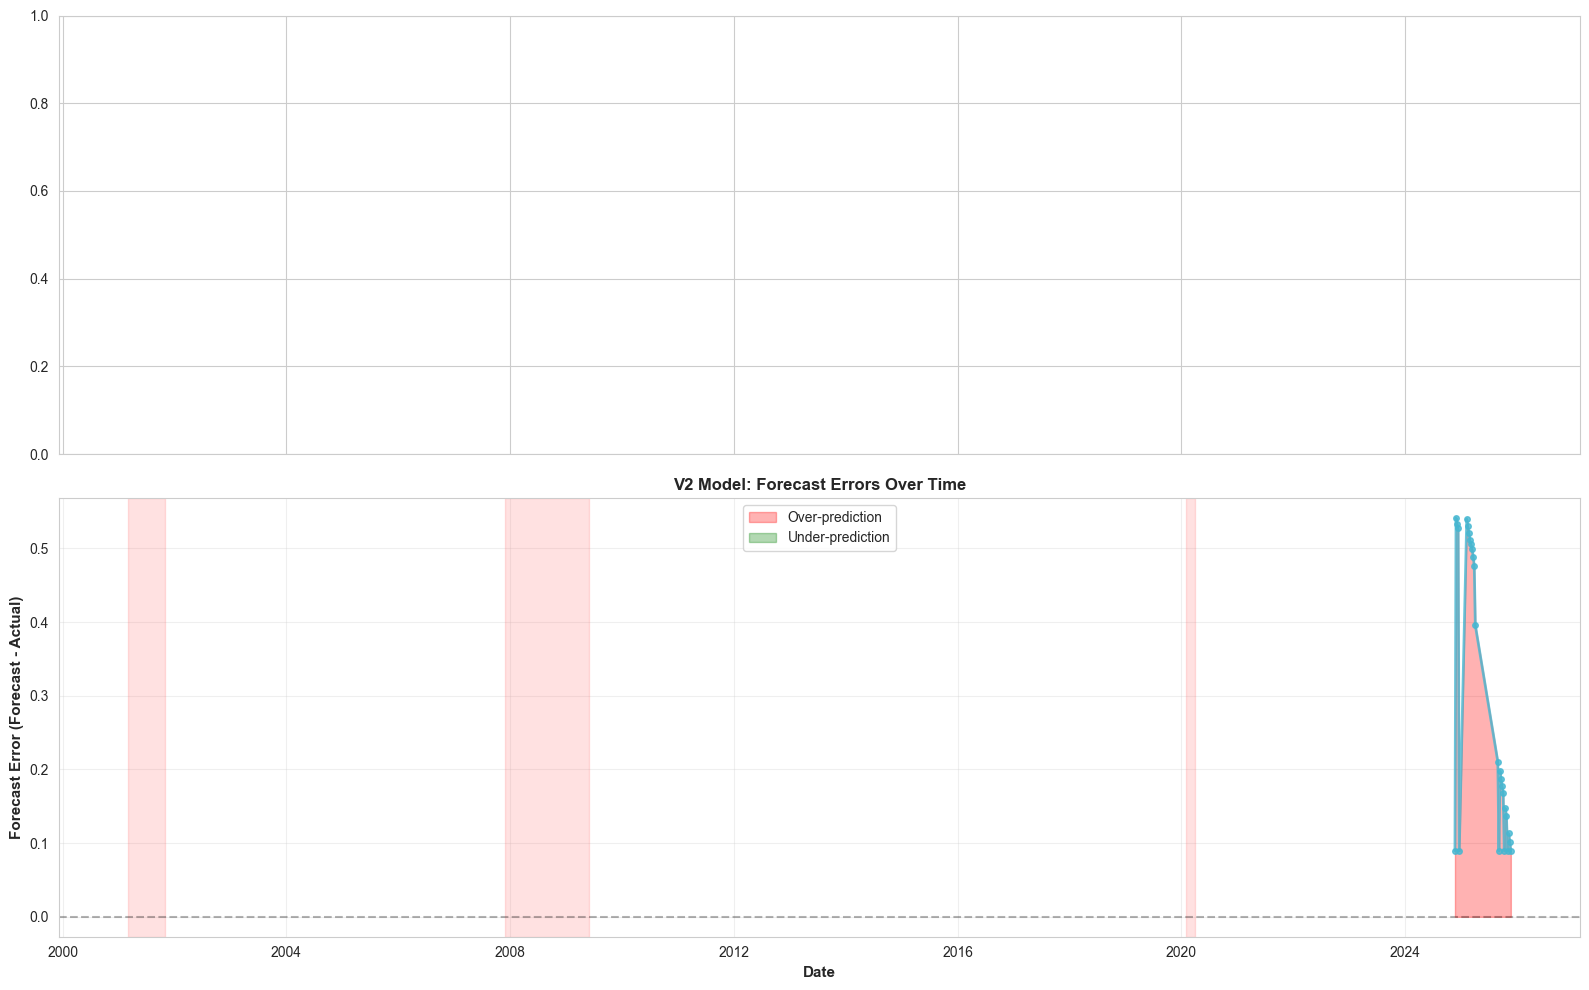

✓ Forecast error charts created


In [33]:
# Plot forecast errors over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# V1 errors
if v1_dates and v1_errors:
    ax1 = axes[0]
    
    # Mark recession periods
    for start, end in recession_periods:
        ax1.axvspan(start, end, alpha=0.2, color=RECESSION_COLOR)
    
    ax1.plot(v1_dates, v1_errors, marker='o', markersize=4, linewidth=2, color=V1_COLOR, alpha=0.8)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax1.fill_between(v1_dates, 0, v1_errors, where=np.array(v1_errors) > 0, 
                     alpha=0.3, color='red', label='Over-prediction')
    ax1.fill_between(v1_dates, 0, v1_errors, where=np.array(v1_errors) < 0, 
                     alpha=0.3, color='green', label='Under-prediction')
    ax1.set_ylabel('Forecast Error (Forecast - Actual)', fontsize=11, fontweight='bold')
    ax1.set_title('V1 Model: Forecast Errors Over Time', fontsize=12, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

# V2 errors
if v2_dates and v2_errors:
    ax2 = axes[1]
    
    # Mark recession periods
    for start, end in recession_periods:
        ax2.axvspan(start, end, alpha=0.2, color=RECESSION_COLOR)
    
    ax2.plot(v2_dates, v2_errors, marker='o', markersize=4, linewidth=2, color=V2_COLOR, alpha=0.8)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax2.fill_between(v2_dates, 0, v2_errors, where=np.array(v2_errors) > 0, 
                     alpha=0.3, color='red', label='Over-prediction')
    ax2.fill_between(v2_dates, 0, v2_errors, where=np.array(v2_errors) < 0, 
                     alpha=0.3, color='green', label='Under-prediction')
    ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Forecast Error (Forecast - Actual)', fontsize=11, fontweight='bold')
    ax2.set_title('V2 Model: Forecast Errors Over Time', fontsize=12, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Forecast error charts created")

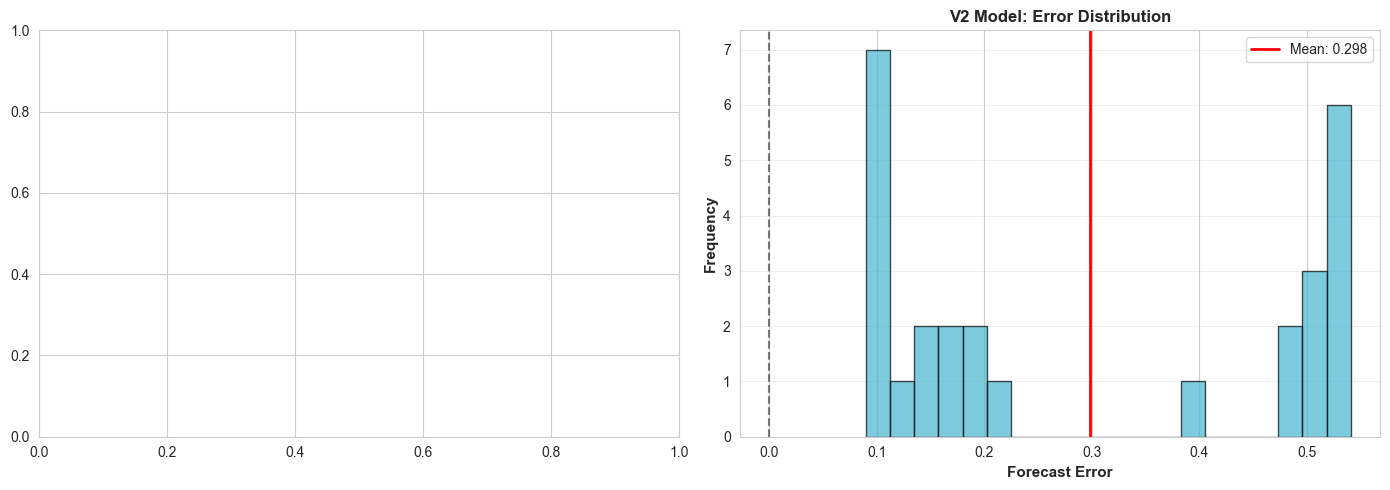

✓ Error distribution charts created


In [34]:
# Analyze error distributions
if v1_errors or v2_errors:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # V1 error distribution
    if v1_errors:
        ax1 = axes[0]
        ax1.hist(v1_errors, bins=20, color=V1_COLOR, alpha=0.7, edgecolor='black')
        ax1.axvline(x=0, color='k', linestyle='--', alpha=0.5)
        ax1.axvline(x=np.mean(v1_errors), color='red', linestyle='-', linewidth=2, label=f'Mean: {np.mean(v1_errors):.3f}')
        ax1.set_xlabel('Forecast Error', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax1.set_title('V1 Model: Error Distribution', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3, axis='y')
    
    # V2 error distribution
    if v2_errors:
        ax2 = axes[1]
        ax2.hist(v2_errors, bins=20, color=V2_COLOR, alpha=0.7, edgecolor='black')
        ax2.axvline(x=0, color='k', linestyle='--', alpha=0.5)
        ax2.axvline(x=np.mean(v2_errors), color='red', linestyle='-', linewidth=2, label=f'Mean: {np.mean(v2_errors):.3f}')
        ax2.set_xlabel('Forecast Error', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('V2 Model: Error Distribution', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Error distribution charts created")
else:
    print("No error data available for distribution analysis")

In [35]:
# Identify periods with largest errors
def identify_worst_forecasts(dates, errors, model_name, n=5):
    """Identify the worst forecast errors."""
    if not dates or not errors:
        print(f"{model_name}: No data available")
        return
    
    # Get absolute errors
    abs_errors = np.abs(errors)
    
    # Get indices of worst forecasts
    worst_indices = np.argsort(abs_errors)[-n:][::-1]
    
    print(f"\n{model_name} - Top {n} Worst Forecasts (by absolute error):")
    print("-" * 70)
    for i, idx in enumerate(worst_indices, 1):
        date = dates[idx]
        error = errors[idx]
        abs_error = abs_errors[idx]
        direction = "Over-prediction" if error > 0 else "Under-prediction"
        print(f"{i}. {date.strftime('%Y-%m-%d')}: Error = {error:+.4f} ({direction}, |error| = {abs_error:.4f})")

# Identify worst forecasts for both models
if v1_dates and v1_errors:
    identify_worst_forecasts(v1_dates, v1_errors, "V1 Model")

if v2_dates and v2_errors:
    identify_worst_forecasts(v2_dates, v2_errors, "V2 Model")


V2 Model - Top 5 Worst Forecasts (by absolute error):
----------------------------------------------------------------------
1. 2024-11-29: Error = +0.5412 (Over-prediction, |error| = 0.5412)
2. 2025-02-07: Error = +0.5398 (Over-prediction, |error| = 0.5398)
3. 2024-12-06: Error = +0.5335 (Over-prediction, |error| = 0.5335)
4. 2025-02-14: Error = +0.5305 (Over-prediction, |error| = 0.5305)
5. 2024-12-13: Error = +0.5272 (Over-prediction, |error| = 0.5272)


## 5. Improvement Suggestions

Based on the backtesting analysis, here are potential areas for improvement:

### Model Improvements
1. **Feature Engineering**: Add more economic indicators or derived features
2. **Weight Optimization**: Use historical data to optimize indicator weights
3. **Temporal Decay Calibration**: Fine-tune decay parameters based on historical performance
4. **Machine Learning**: Consider ML models (Random Forest, XGBoost) trained on historical data

### Data Quality
1. **Missing Data Handling**: Improve strategies for handling missing or delayed data
2. **Data Frequency**: Consider higher-frequency data where available
3. **Alternative Data**: Incorporate non-traditional data sources

### Calibration
1. **Probability Calibration**: Apply calibration techniques (Platt scaling, isotonic regression)
2. **Ensemble Methods**: Combine multiple models for better calibration
3. **Uncertainty Quantification**: Add confidence intervals using bootstrap methods

### Evaluation
1. **More Historical Data**: Extend backtesting to earlier periods if data available
2. **Cross-Validation**: Implement time-series cross-validation
3. **Scenario Analysis**: Test model performance under different economic scenarios

In [36]:
# Print summary statistics
print("="*70)
print("BACKTESTING ANALYSIS SUMMARY")
print("="*70)

if v1_results:
    print(f"\nV1 Model:")
    print(f"  Total Backtests: {len(v1_results)}")
    if v1_metrics and v1_metrics['brier_score'] is not None:
        print(f"  Brier Score: {v1_metrics['brier_score']:.4f}")
        print(f"  Mean Probability: {v1_metrics['mean_probability']:.4f}")
        print(f"  Sharpness: {v1_metrics['sharpness']:.4f}")
    if v1_errors:
        print(f"  Mean Absolute Error: {np.mean(np.abs(v1_errors)):.4f}")
        print(f"  RMSE: {np.sqrt(np.mean(np.array(v1_errors)**2)):.4f}")

if v2_results:
    print(f"\nV2 Model:")
    print(f"  Total Backtests: {len(v2_results)}")
    if v2_metrics and v2_metrics['brier_score'] is not None:
        print(f"  Brier Score: {v2_metrics['brier_score']:.4f}")
        print(f"  Mean Probability: {v2_metrics['mean_probability']:.4f}")
        print(f"  Sharpness: {v2_metrics['sharpness']:.4f}")
    if v2_errors:
        print(f"  Mean Absolute Error: {np.mean(np.abs(v2_errors)):.4f}")
        print(f"  RMSE: {np.sqrt(np.mean(np.array(v2_errors)**2)):.4f}")

if v1_results and v2_results and v1_metrics and v2_metrics:
    if v1_metrics['brier_score'] is not None and v2_metrics['brier_score'] is not None:
        improvement = v1_metrics['brier_score'] - v2_metrics['brier_score']
        pct_improvement = (improvement / v1_metrics['brier_score']) * 100
        print(f"\nModel Comparison:")
        print(f"  Brier Score Improvement: {improvement:.4f} ({pct_improvement:+.2f}%)")
        print(f"  V2 is {'BETTER' if improvement > 0 else 'WORSE'} than V1")

print("\n" + "="*70)
print("✓ Backtesting analysis complete")

BACKTESTING ANALYSIS SUMMARY

V2 Model:
  Total Backtests: 27
  Brier Score: 0.1251
  Mean Probability: 0.2980
  Sharpness: 0.1904
  Mean Absolute Error: 0.2980
  RMSE: 0.3537

✓ Backtesting analysis complete


## Conclusion

This notebook has analyzed the historical backtesting results for both v1 and v2 recession forecast models.

### Key Takeaways
- Historical performance provides insights into model accuracy and calibration
- Brier score and calibration metrics help quantify forecast quality
- Error analysis reveals patterns and areas for improvement
- Comparing v1 and v2 shows the impact of enhancements

### Next Steps
1. Review the improvement suggestions above
2. Implement promising enhancements
3. Re-run backtesting to validate improvements
4. Continue monitoring real-time forecast performance